# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

#### This notebook explores Latent Dirichlet Allocation concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [1]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_theme(style='white')

# Project-specific imports
import glob
from glob import glob
import nltk
nltk_resources = [
    'tokenizers/punkt', 
        'averaged_perceptron_tagger_eng',
            'corpora/stopwords', 
                'help/tagsets'
                ]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)

# Scikit Learn
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF # Note importing of two topic modelers

# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
    # If a file is in /sources/, access it by telling the system to look at that path as well as current path
    sys.path.append(os.path.join(os.getcwd(), 'sources'))
    source_dir = "sources"
    source_files_paths = glob(f"{source_dir}/*.xml")
    # Same for csvs
    sys.path.append(os.path.join(os.getcwd(), 'csvs'))
    csvs_dir = "csvs"
    csvs_files_paths = glob(f"{csvs_dir}/*.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Setting OHCO

In [2]:
# Define OHCO
OHCO = ['year', 'mth_day', 'doc_id', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    DOCS = OHCO[:3],
    MTH_DAY = OHCO[:2],
    YEAR = OHCO[:1]
)

bag = 'DOCS'

### Prepping Data

In [3]:
TOKENS = pd.read_csv('csvs/CORPUS/CORPUS.csv').set_index(OHCO)
TOKENS.head()

pos pos_group token_str  term_str
year mth_day doc_id sent_num token_num                                   
2018 12-18   0      0        0           DT        DT       The       the
                             1           JJ        JJ  southern  southern
                             2           NN        NN      cone      cone
                             3           IN        IN        of        of
                             4          NNP        NN     South     south

In [4]:
# Creating a DOCS table, filtering for nouns!
# Group by bag(doc_id), join strings, convert to df and format
DOCS = TOKENS[TOKENS.pos.str.match(r'.+')]\
    .groupby('doc_id').term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

DOCS.head()

,doc_str
doc_id,
0,the southern cone of south america has been th...
1,anthropogenic ocean warming threatens the surv...
2,environmental changes eg global warming climat...
3,neither reducing the use of antibiotics nor di...
4,by 2050 the global human population will have ...


### Creating Vector Space

In [5]:
# Use english stopwords
my_stop_words = list(text.ENGLISH_STOP_WORDS)

# Built engine and model, build DFs!!
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

,0001,001,002,004,005,007,01,02,025,03,...,years,yellow,yield,yielded,young,zero,zone,zones,µl,µm
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,1,...,4,0,0,0,0,0,1,0,0,0
1,6,0,0,0,22,0,1,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2,0,0,0,0,2,0,0,0,0,0,...,2,1,1,0,0,0,0,0,0,0
3,2,2,0,0,7,3,4,2,2,0,...,0,0,0,0,0,0,0,0,2,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,17,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,6,0,1,0,0,1,0,0,0,0,...,6,0,0,0,1,1,15,35,0,0
88,5,0,1,0,6,0,0,1,0,0,...,8,0,1,0,0,1,0,6,0,0
89,2,0,0,0,0,1,1,0,0,0,...,22,0,0,0,1,2,0,0,0,0


A sparse matrix with many zeros

In [6]:
#settings 
n_topics = 20
max_iter = 100
n_top_terms = 9

TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

# Generate model
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)

topic_model = topic_engine.fit_transform(count_model)

### Create THETA

In [7]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(axis=None) # Use default color map
# Save
THETA.to_csv("csvs/LDA/THETA.csv")
THETA.head()

topic_id,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
doc_id,,,,,,,,,,,,,,,,,,,,
0,0.000035,0.000035,0.000035,0.000035,0.000035,0.000035,0.000035,0.000035,0.000035,0.721283,0.000035,0.000035,0.000035,0.000035,0.000035,0.058634,0.000035,0.000035,0.219482,0.000035
1,0.000017,0.010174,0.771450,0.022332,0.064457,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.003786,0.127567,0.000017,0.000017,0.000017,0.000017,0.000017
2,0.000033,0.000033,0.372718,0.030102,0.037849,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.056168,0.050988,0.412343,0.000033,0.039402,0.000033,0.000033,0.000033
3,0.000029,0.000029,0.034298,0.000029,0.000029,0.741318,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.067501,0.000029,0.156414,0.000029,0.000029,0.000029,0.000029,0.000029
4,0.000058,0.000058,0.000058,0.000058,0.000058,0.998891,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058


### Creating PHI

(Sort of a topic model)

In [8]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
# Save
PHI.to_csv("csvs/LDA/PHI.csv")
PHI.T.sample(10).T.style.background_gradient(axis=None)


term_str,running,feedback,similar,95,stressors,performance,female,discussion,package,help
topic_id,,,,,,,,,,
T00,1.300994,0.050000,0.050000,2.003556,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T01,1.771303,7.879927,5.105360,3.303474,0.050000,12.255888,0.050000,10.742711,0.050000,42.548425
T02,0.050000,5.284024,10.342437,10.309193,8.723463,0.050000,0.050000,0.050000,4.857286,0.050000
T03,0.050000,0.050000,21.285640,1.444183,0.050000,2.232666,0.050000,0.050000,0.050000,19.658700
T04,2.911915,0.050000,36.855162,3.580941,0.050000,0.050000,16.216823,1.059082,19.943647,7.789475
T05,0.050000,0.050000,3.245021,0.050000,13.041963,0.050000,0.050000,0.050000,0.050000,2.066258
T06,1.083109,4.180202,25.694044,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,5.386876
T07,0.050000,0.050000,4.200854,1.608955,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T08,0.050000,0.050000,29.703016,5.792861,0.050000,0.050000,1.881548,0.050000,0.050000,3.973051


### Creating TOPICS, Obtaining Top Terms, Sorting

In [9]:
# Stacking PHi, grouping by topic id and joining, only keeping the number of top terms chosen
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
# Save
TOPICS.to_csv("csvs/LDA/TOPICS.csv")
TOPICS

,top_terms
topic_id,
T00,eqnarray drought temperature end values precip...
T01,technology city model network information publ...
T02,rates temperature coral larvae microbial heat ...
T03,species diversity fish community prey communit...
T04,species samples expression sampling gene seque...
T05,bacteria production resistance crop concentrat...
T06,predicted future model suitable habitat specie...
T07,livestock populations properties population pr...
T08,species breeding station range new records bir...


In [10]:
# Sort by Doc Weight using the sum to calculate
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\student\AppData\Local\Temp\ipykernel_21956\3231892464.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\student\AppData\Local\Temp\ipykernel_21956\3231892464.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_sum,term_freq
topic_id,,,
T18,species areas area distribution model region south potential range,9.976631,0.091640
T09,populations genetic population species lineages diversity analyses samples sequences,8.451863,0.084703
T14,populations population survival age size model effects effect number,6.605330,0.068945
T02,rates temperature coral larvae microbial heat corals conditions density,6.501403,0.073037
T04,species samples expression sampling gene sequences bacterial sample number,5.865548,0.057880
T19,soil water plant content area plants root stress showed,5.586282,0.054476
T15,species vegetation forest plots trees class tree soil sites,5.425658,0.069392
T03,species diversity fish community prey communities interactions host research,5.005393,0.070039
T17,size coral group reefs individuals ph depth surface reef,4.311463,0.036926


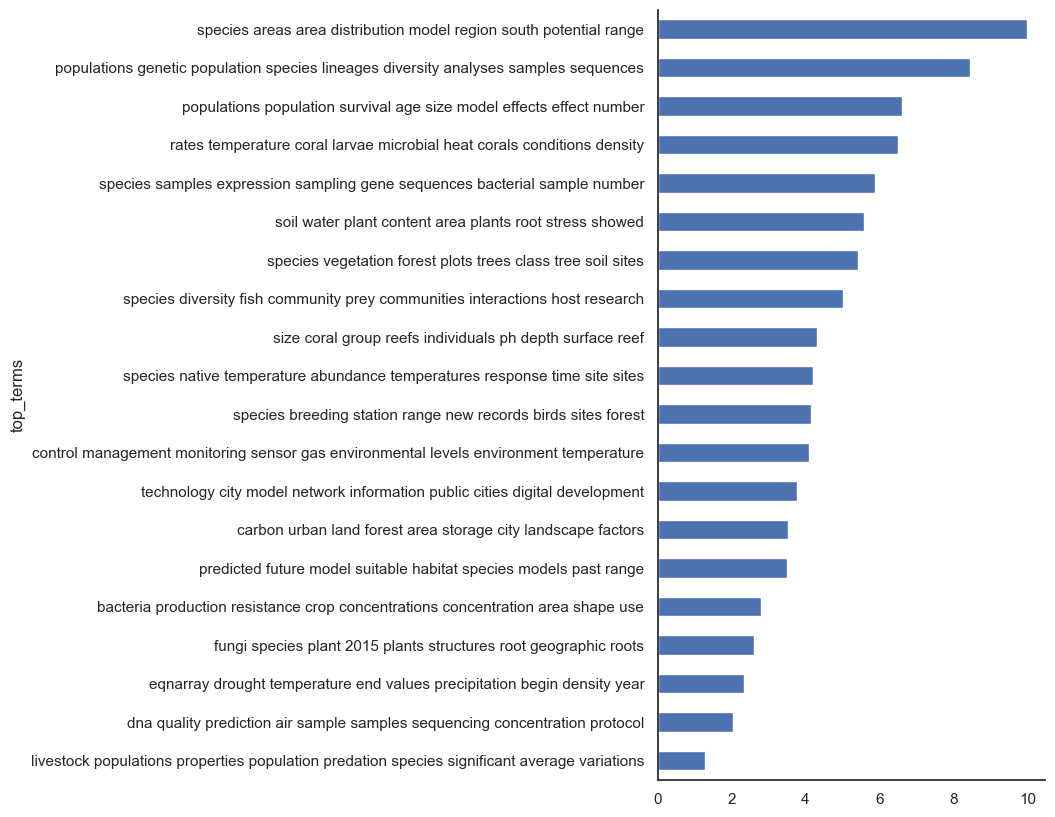

In [11]:
# Again, sort values and plot it for another visualization
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

### Exploring by Year

In [12]:
# Read in LIB for metadata
LIB = pd.read_csv('csvs/LIB/LIB.csv').set_index('doc_id')

# Join the two
THETA_YR = pd.merge(LIB, THETA, on=LIB.index)

THETA_YR.drop(columns=[ 'doc_1st_author', 'sent_str', 'doc_title', 'num_words', 'num_chars'], inplace=True)

THETA_YR = THETA_YR.rename(columns={'key_0': 'doc_id'})

# Settings
THETA_YR.set_index(['doc_id', 'year'], inplace=True)

In [13]:
# Group by year
TOPIC_YR = THETA_YR.groupby(THETA_YR.index.get_level_values('year')).mean()
# Transpose, settings
TOPIC_YR.T.style.background_gradient(axis=0, cmap="YlGnBu")

year,2013,2018,2023
T00,0.053231,0.017391,0.019588
T01,0.093802,0.018546,0.037596
T02,0.072067,0.089849,0.050805
T03,0.016647,0.046205,0.080977
T04,0.048084,0.058596,0.076540
T05,0.102416,0.005724,0.020278
T06,0.064814,0.032400,0.030371
T07,0.001066,0.006620,0.027223
T08,0.017223,0.043654,0.060029
T09,0.118948,0.101752,0.068811


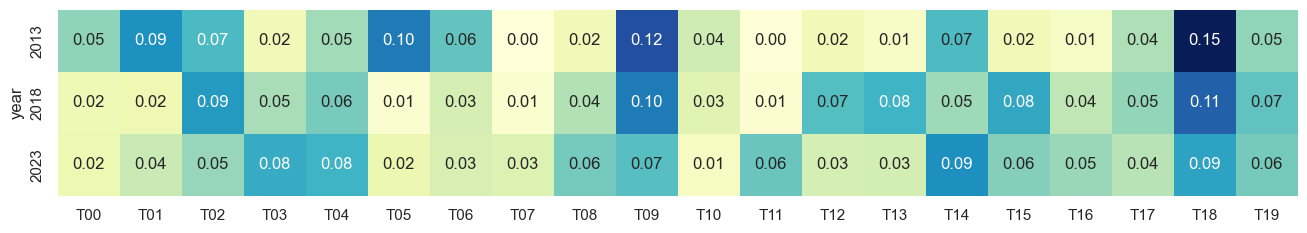

In [14]:
# Set fig size so that figure can hold annotations
fig = plt.subplots(figsize=(16, 16))
# Round annotations so they fit better, make the cells square
sns.heatmap(TOPIC_YR, cmap="YlGnBu", cbar=None, annot=True, fmt=".2f", square=True)
plt.show()

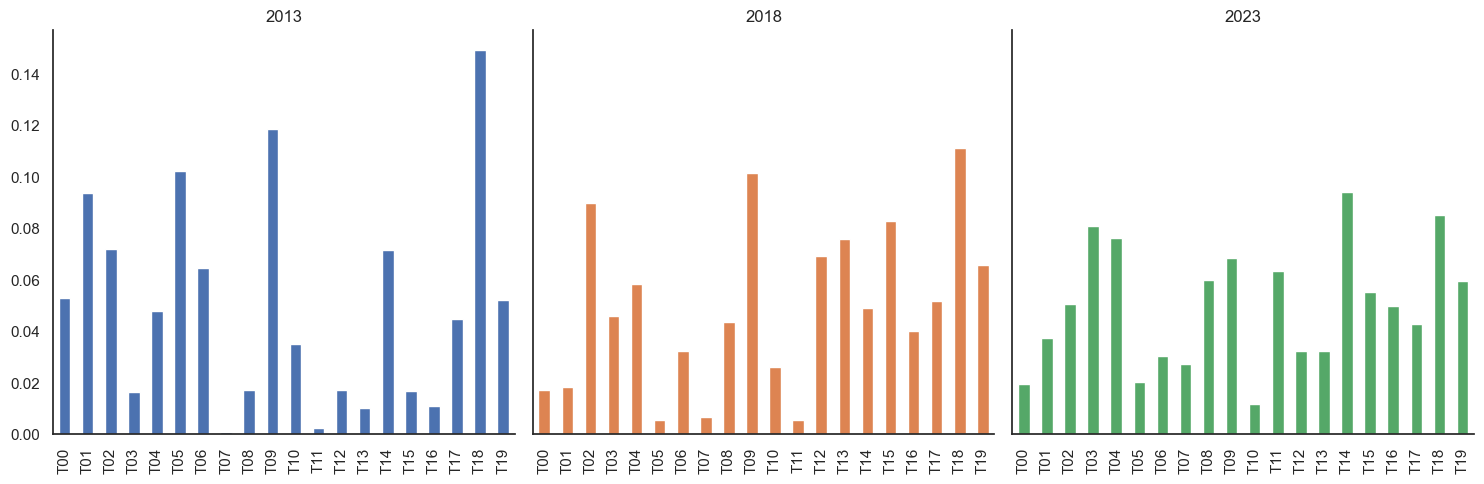

In [15]:
TOPIC_YR.T.plot.bar(subplots=True, figsize=(15,5), legend=False, sharey=True, layout=(1,3)) # Layout param from claude, was using fig, ax = sublpots(1,3)
sns.despine()
plt.tight_layout()
plt.show()

(See Riff in FinalProject.ipynb for Analysis)

### Applying PCA

**Goals:**

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

In [16]:
# Use 3 components - cannot use more than the number of documents
pca_engine = PCA(n_components=3)

# Apply it to the TFIDF table to create a document count matrix
DCM_THETA = pd.DataFrame(pca_engine.fit_transform(THETA_YR), index=THETA_YR.index)

DCM_THETA.columns = ["PC{}".format(i) for i in DCM_THETA.columns]

DCM_THETA

,,PC0,PC1,PC2
doc_id,year,,,
9,2013,0.610293,-0.240758,-0.009699
60,2013,-0.283220,-0.165832,-0.010903
69,2013,-0.238938,-0.113011,0.276035
42,2013,-0.148370,-0.060570,0.153721
13,2013,-0.122589,-0.050537,0.044612
...,...,...,...,...
23,2023,0.018763,0.067629,0.036253
65,2023,-0.054498,0.089699,-0.107833
67,2023,-0.238285,-0.097227,0.805068


In [17]:
# Make a components table that essentially documents the explained variance of each term
# I.e., how much each term is part of any given component
# This will help in defining the components' meanings 
COMPS_THETA = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
# Formatting and settings (columns, index, transpose for easy viewing)
#COMPS_THETA.columns = ["T0{}".format(i) for i in THETA_YR.columns]
COMPS_THETA.index.name = 'PC'
COMPS_THETA.T

PC,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.006682,-0.010280,-0.060757,0.009350,-0.032241,-0.016948,0.006643,-0.000908,-0.001591,0.184033,-0.005677,-0.008262,-0.021217,-0.013658,-0.044013,-0.011613,-0.013551,-0.010815,0.102448,-0.044261
1,0.001836,0.009961,-0.037801,0.003305,-0.038868,-0.008939,0.032985,0.005631,0.012903,-0.119974,-0.003978,0.001379,-0.002967,0.015043,-0.019033,0.013023,0.006779,-0.010984,0.162698,-0.023001
2,-0.003601,-0.000835,-0.024049,-0.000412,-0.018438,0.009755,-0.011432,-0.000937,0.009929,0.001895,-0.005307,0.001158,-0.000182,0.008827,0.150504,-0.030504,-0.006577,0.014673,0.000528,-0.094997


In [18]:
# A function to visualize the principal components
# Inputs: The DCM df, PCs a and b
# Size the points based on the mean document weight of each topic (using the THETA table)
# Color the points basd on a metadata feature from the LIB table.
def vis_pcs(DCM, a, b):
    return px.scatter(DCM, f"PC{a}", f"PC{b}",
                      color=DCM.index.get_level_values('year').astype(str),
                      #size= THETA_YR['mean'],
                      hover_name=DCM.index.get_level_values('doc_id').astype(str),
                      marginal_x='box', height=800)

# Another function for visualization
# Inputs: The COMPS df, PCs and b
def vis_loadings(COMPS, a, b):
    return px.scatter(COMPS, a, b, 
                      text=COMPS.index,
                      hover_name=COMPS.index,
                      marginal_x='box', 
                      height=800)

In [19]:
vis_pcs(DCM_THETA, 0, 1)

In [20]:
vis_loadings(COMPS_THETA, 0, 1)